In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/telco_customer_churn.csv")
df.shape


(7043, 21)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df["TotalCharges"].apply(lambda x: x.strip()).eq("").sum()

np.int64(11)

In [4]:
df[df["TotalCharges"].str.strip() == ""][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [5]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")
df["TotalCharges"] = df["TotalCharges"].astype(float)

df["TotalCharges"].dtype

dtype('float64')

In [6]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

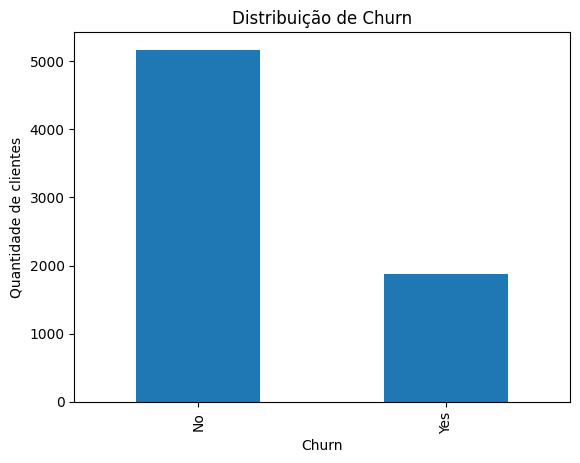

In [7]:
import matplotlib.pyplot as plt

df["Churn"].value_counts().plot(kind="bar", title="Distribuição de Churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade de clientes")
plt.show()

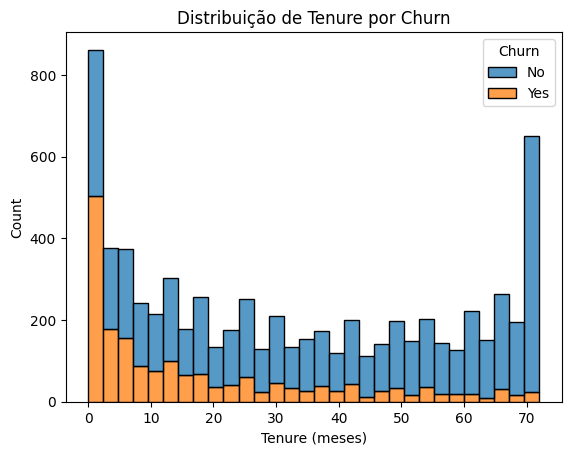

In [8]:
import seaborn as sns

sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30)
plt.title("Distribuição de Tenure por Churn")
plt.xlabel("Tenure (meses)")
plt.show()

In [9]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [10]:
df.to_csv("../data/processed/telco_churn_clean.csv", index=False)